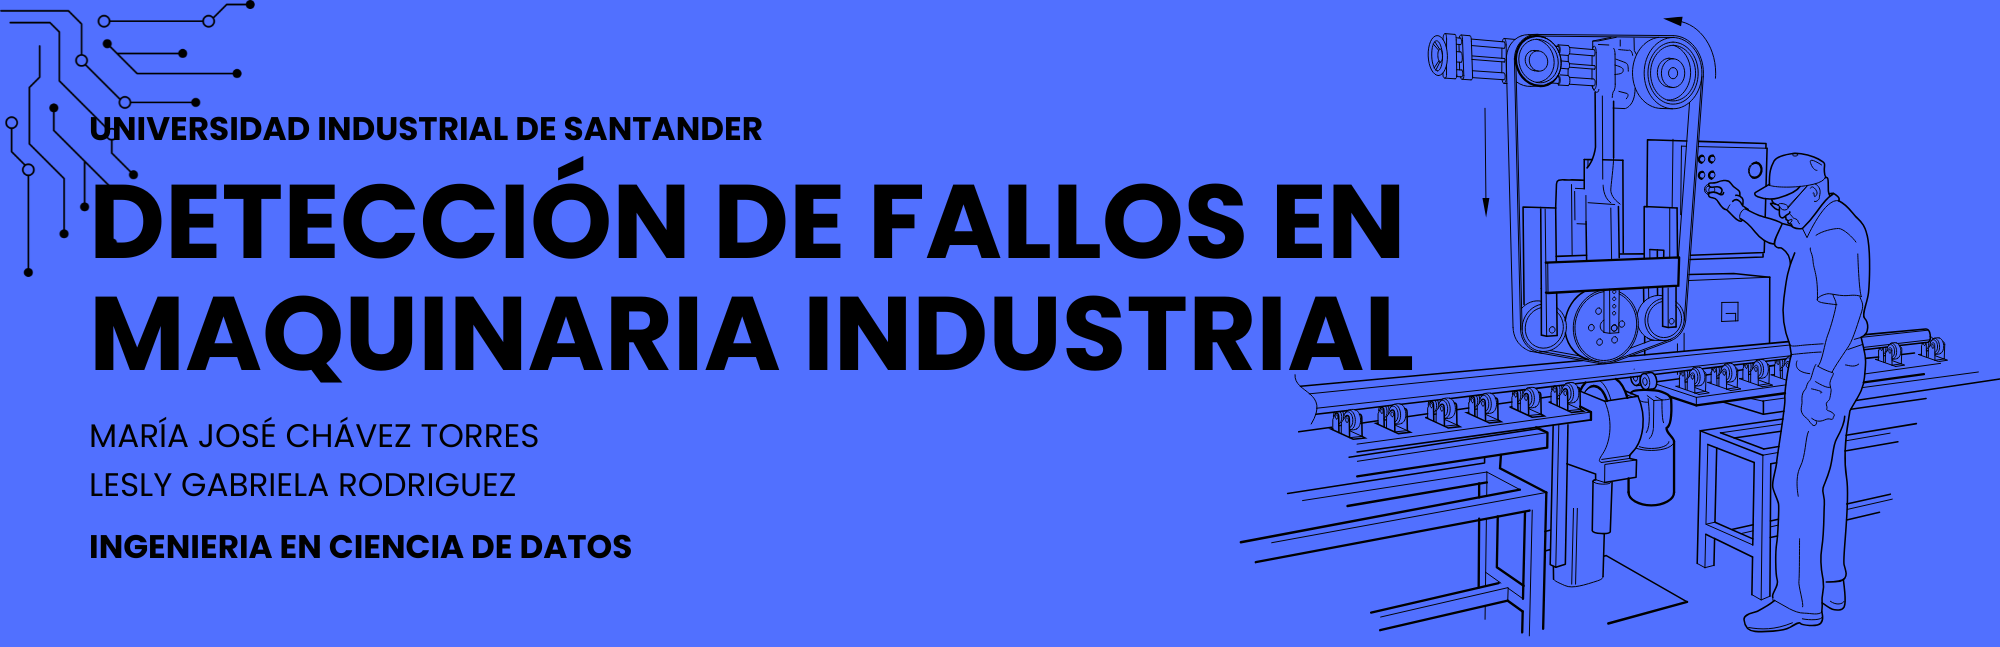



# **Proyecto de Machine Learning: Detección de Fallos en Mantenimiento Predictivo**



##         Objetivo
El objetivo de este análisis exploratorio de datos es comprender la estructura, calidad y comportamientos de las variables del dataset, con el fin de identificar patrones relevantes que permitan, construir modelos de aprendizaje automático capaces de predecir fallas en la maquinaria, Esto detectar valores atípicos, entender la relación entre las variables predictoras y la variable objetivo, y caracterizar el desbalance de clases presentes el en dataset.

### Origen de los datos
Se utiliza el dataset **"Machine Predictive Maintenance Classification"** den Kaggle, contiene 10.000 registros de operación de una máquina
de fresado industrial. Cada registro corresponde a una medición tomada durante el
funcionamiento de la máquina e incluye variables de proceso capturadas por sensores
(temperatura ambiente, temperatura del proceso, velocidad rotacional, torque y desgaste
de herramienta), así como la calidad/tipo de producto fabricado (`Type`) y si la máquina
falló o no (`Target`), junto con el tipo de falla presentada (`Failure Type`) cuando aplica


### Desafíos identificados
- **Desbalance de clases:** solo el 3.39% de los registros son fallas (339 de 10.000),
  por lo que se usarán métricas como F1-score y recall en lugar de accuracy simple.
- **Fallas multicausa:** existen 5 tipos de falla distintos, y su ocurrencia depende de
  combinaciones de variables (torque, velocidad, desgaste) más que de una sola por sí sola.

## Justificación del uso de Machine Learning

Este problema requiere Machine Learning porque la ocurrencia de una falla no depende de
un único umbral en una variable, sino de combinaciones entre temperatura, torque,
velocidad y desgaste de herramienta que un modelo puede aprender automáticamente mejor
que reglas fijas definidas a mano. Además, se busca tanto predecir si la máquina va a
fallar (binario) como identificar qué tipo de falla es más probable (multiclase), tareas
que un modelo entrenado puede aplicar en tiempo real sobre nuevas lecturas de sensores
para anticipar fallas y reducir tiempos de inactividad no planificados.

In [1]:
#@title librerias importadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar el dataset
url = 'https://raw.githubusercontent.com/gabbrod/Proyecto_ML/refs/heads/main/data/predictive_maintenance.csv'
df = pd.read_csv(url)

###Información básica del Dataset:
Se revisan las dimensiones, tipos de datos y primeras filas del dataset para verificar
que la carga fue correcta y entender la estructura general de las variables.




In [3]:

print("---------------------------------------------")
print("Columnas del Dataset: \n",df.columns)
print("\n---------------------------------------------")
print("\nTamaño del Dataset: ",df.shape)
print("\n---------------------------------------------")
print("\nInformacion de cada columna:\n",df.dtypes)


print("---------------------------------------------")
df.head(10)


---------------------------------------------
Columnas del Dataset: 
 Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

---------------------------------------------

Tamaño del Dataset:  (10000, 10)

---------------------------------------------

Informacion de cada columna:
 UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object
---------------------------------------------


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


###Valores Nulos:
Se verifica la presencia de valores faltantes en cada columna. El dataset no presenta
valores nulos, lo cual simplifica el proceso siguiente.


In [4]:
for columna in df.columns:
    nulos = np.sum(pd.isnull(df[columna]))
    print(columna, "valores nulos: ", nulos)

UDI valores nulos:  0
Product ID valores nulos:  0
Type valores nulos:  0
Air temperature [K] valores nulos:  0
Process temperature [K] valores nulos:  0
Rotational speed [rpm] valores nulos:  0
Torque [Nm] valores nulos:  0
Tool wear [min] valores nulos:  0
Target valores nulos:  0
Failure Type valores nulos:  0


In [5]:
#@title Valores duplicados
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


### Estadística descriptiva:
Se calculan medidas de tendencia central y dispersión para las variables numéricas,
lo que permite identificar rangos, escalas y posibles asimetrías antes de pasar al
análisis visual.

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


### Frecuencia de valores por variable
Se revisa la distribución de frecuencias de cada variable, incluyendo `Type`, para
identificar categorías predominantes y confirmar el desbalance en la variable `Target`.

In [7]:

print("----------------------------------------------------")
print("Frecuencia de cada uno de los datos de cada columna")
print("----------------------------------------------------")
columnas_interes = ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
for value in columnas_interes:
    frecuencia = df[value].value_counts()
    print(frecuencia)
print("--------------------------------------------------")

----------------------------------------------------
Frecuencia de cada uno de los datos de cada columna
----------------------------------------------------
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Air temperature [K]
300.7    279
298.9    231
297.4    230
300.5    229
298.8    227
        ... 
304.4      7
296.0      6
295.3      3
295.4      3
304.5      1
Name: count, Length: 93, dtype: int64
Process temperature [K]
310.6    317
310.8    273
310.7    266
308.6    265
310.5    263
        ... 
306.9      4
313.7      4
305.8      3
305.7      2
313.8      2
Name: count, Length: 82, dtype: int64
Rotational speed [rpm]
1452    48
1435    43
1447    42
1469    40
1429    40
        ..
1808     1
2424     1
2158     1
2097     1
1788     1
Name: count, Length: 941, dtype: int64
Torque [Nm]
40.2    52
35.8    50
42.4    50
38.5    50
37.7    49
        ..
9.8      1
14.3     1
67.2     1
63.5     1
15.5     1
Name: count, Length: 577, dtype: int64
Tool wear [min]
0   

## Variable Objetivo

La variable a predecir es **`Target`**, de tipo binaria: **1** indica que la máquina
presentó una falla y **0** que no falló. De los 10.000 registros, solo 339
corresponden a fallas (**3.39%**), lo que evidencia un fuerte desbalance de clases. Adicionalmente, existe la variable `Failure Type`, que detalla el tipo
de falla presentada (disipación de calor, potencia, sobreesfuerzo, desgaste de
herramienta o fallas aleatorias) para los casos donde `Target = 1`, y que será relevante
si se aborda la tarea de clasificación multiclase.

### Promedios por clase (Target)
Se comparan los valores promedio de las variables numéricas entre máquinas que fallaron
y las que no. Se observa que las máquinas que fallaron tienen en promedio mayor torque
(50.2 Nm vs 39.6 Nm) y mayor desgaste de herramienta (143.8 min vs 106.7 min), lo cual
sugiere que estas variables están relacionadas con la ocurrencia de fallos.

In [8]:
print("-------------------------------------------------------")
print("Promedio de cada variable de acuerdo al tipo de fallo")
print("-------------------------------------------------------")

df.groupby('Target').mean(numeric_only=True)


-------------------------------------------------------
Promedio de cada variable de acuerdo al tipo de fallo
-------------------------------------------------------


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,,
0,5012.878791,299.973999,309.995570,1540.260014,39.629655,106.693717
1,4647.722714,300.886431,310.290265,1496.486726,50.168142,143.781711


###Outliers de las columnas numericas:
Se utiliza el método de rango intercuartílico (IQR) para identificar valores atípicos
en las variables numéricas, ya que es un método robusto que no asume una distribución
específica de los datos.

In [9]:
def obtener_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

outliers_ambiente, min_amb, max_amb = obtener_outliers_iqr(df, "Air temperature [K]")
outliers_proceso, min_fab, max_fab = obtener_outliers_iqr(df, "Process temperature [K]")
outliers_rotacion, min_rot, max_rot = obtener_outliers_iqr(df, "Rotational speed [rpm]")
outliers_torque, min_torque, max_torque = obtener_outliers_iqr(df, "Torque [Nm]")

#Temperatura ambiente
print("Temperatura ambiente -> Límites IQR: [", min_amb, ",", max_amb, "]")
print("Cantidad de outliers:", len(outliers_ambiente))
print("-------------------------------------------------------------")
#Temperatura maquina
print("Temperatura de proceso -> Límites IQR: [", min_fab, ",", max_fab, "]")
print("Cantidad de outliers:", len(outliers_proceso))
print("-------------------------------------------------------------")
#Rotación
print("velocidad de rotación -> Límites IQR: [", min_fab, ",", max_fab, "]")
print("Cantidad de outliers: ", len(outliers_rotacion))
print("muestra de outliers: ", outliers_rotacion["Rotational speed [rpm]"].head(10))
print("-------------------------------------------------------------")
#Torque
print("Torque -> Límites IQR: [", min_torque, ",", max_torque, "]")
print("Cantidad de outliers:", len(outliers_torque))
print("muestra de outliers: ", outliers_torque["Torque [Nm]"].head(10))


Temperatura ambiente -> Límites IQR: [ 293.5 , 306.29999999999995 ]
Cantidad de outliers: 0
-------------------------------------------------------------
Temperatura de proceso -> Límites IQR: [ 305.35 , 314.55000000000007 ]
Cantidad de outliers: 0
-------------------------------------------------------------
velocidad de rotación -> Límites IQR: [ 305.35 , 314.55000000000007 ]
Cantidad de outliers:  418
muestra de outliers:  14     2035
50     2861
70     1924
101    1991
155    1987
172    1924
177    1988
194    2678
267    1954
284    2051
Name: Rotational speed [rpm], dtype: int64
-------------------------------------------------------------
Torque -> Límites IQR: [ 12.800000000000011 , 67.19999999999999 ]
Cantidad de outliers: 69
muestra de outliers:  50       4.6
194     10.7
380     12.8
463      4.2
603     71.6
847      5.6
880     76.2
1016    68.3
1095     9.3
1124    69.0
Name: Torque [Nm], dtype: float64


### Estrategia para el manejo de outliers

Dado que las fallas son eventos poco frecuentes (3.39% del dataset), no se eliminarán
los outliers identificadosmcon el método IQR, ya que varios de ellos podrían
corresponder especificamente a los casos donde la máquina falló (por ejemplo, valores
extremos de torque o desgaste de herramienta), y quitarlo implicaría perder
información valiosa para el modelo. En su lugar, se prefiere:
(1) mantener los datos
originales para modelos basados en árboles (Random Forest, XGBoost), que son robustos a
outliers por naturaleza, y
(2) si se llegan a usar modelos sensibles a la escala
(regresión logística, SVM, KNN), aplicar `RobustScaler` en lugar de estandarización
tradicional, ya que este escalador usa mediana e IQR y es menos sensible a valores
atípicos que la media y desviación estándar.

#**Visualización de los datos**

Los histogramas muestran la distribución general de cada variable numérica en todo el dataset, sin diferenciar entre máquinas que fallaron o no. Permite identificar la forma de cada distribución (normal, sesgada, etc.), el rango de valores más frecuente y posibles concentraciones o asimetrías en los datos.

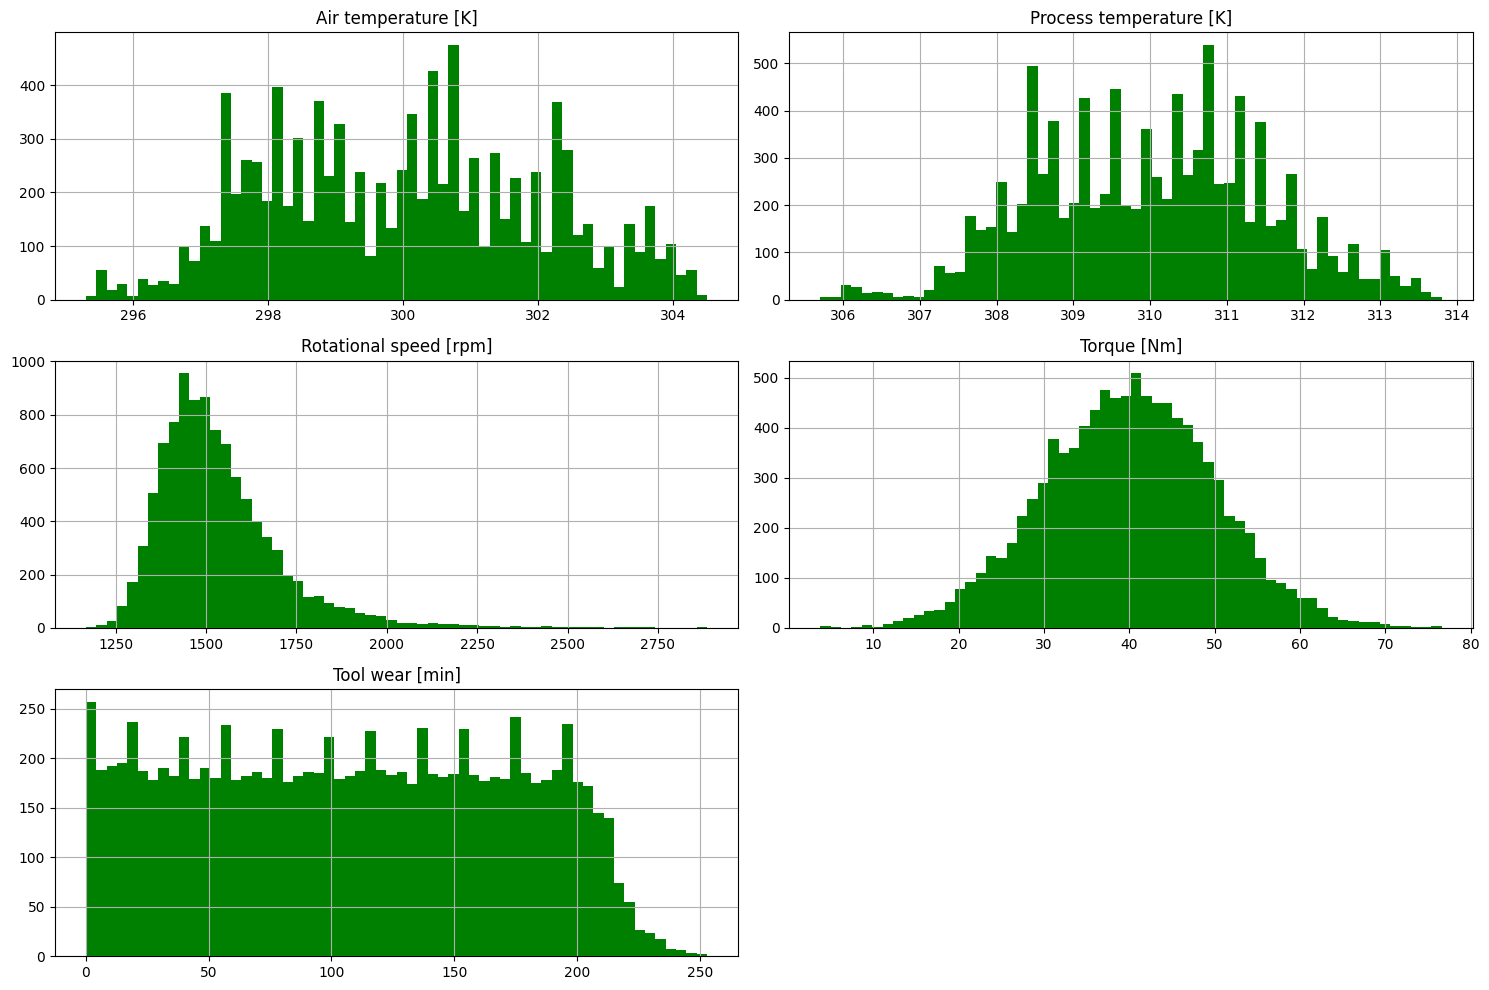

In [10]:
variables_numericas = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df[variables_numericas].hist(figsize=(15, 10), bins=60, color="green")
plt.tight_layout()
plt.show()

##**Coeficiente de asimetría por variable numérica**

In [21]:
skewness_df = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                   'Torque [Nm]', 'Tool wear [min]']].skew().round(3).reset_index()
skewness_df.columns = ['Variable', 'Skewness']
skewness_df

,Variable,Skewness
0,Air temperature [K],0.114
1,Process temperature [K],0.015
2,Rotational speed [rpm],1.993
3,Torque [Nm],-0.010
4,Tool wear [min],0.027


## **Air Temperature [k] y Process Temperature [k]**

**Tipo de variable:** Cuantitativa continua.

**Análisis:** Presentan distribuciones no normales sin presencia de valores atípicos (outliers). Se utiliza la mediana como medida de tendencia central y el rango intercuartílico (IQR) como medida de dispersión:

**Air temperature [K]:** Mediana = $300.10$ K (IQR: $Q_1 = 298.30$ K, $Q_3 = 301.50$ K, $\text{IQR} = 3.20$ K)

**Process temperature [K]:** Mediana = $310.10$ K (IQR: $Q_1 = 308.80$ K, $Q_3 = 311.10$ K, $\text{IQR} = 2.30$ K)

## **Rotational speed [rpm]**

**Tipo de variable:** Cuantitativa continua.

**Análisis:** Presenta una distribución asimétrica positiva (sesgada a la derecha) con presencia de valores atípicos en la cola superior. Debido al sesgo, se emplea la mediana como medida de tendencia central y el rango intercuartílico (IQR) para la dispersión:

**Rotational speed [rpm]:** Mediana = $1503.00\text{ rpm}$ (IQR: $Q_1 = 1423.00\text{ rpm}$, $Q_3 = 1612.00\text{ rpm}$, $\text{IQR} = 189.00\text{ rpm}$)

## **Torque [Nm]**

**Tipo de variable:** Cuantitativa continua.

**Análisis:** Presenta una distribución simétrica (aproximadamente normal) con presencia de valores atípicos en las colas. Al mantener simetría, la medida de tendencia central óptima es la media y la de dispersión es la desviación estándar:

**Torque [Nm]:** $\mu = 39.98 \pm \sigma = 9.96 $ Nm

## **Tool wear [min]**

**Tipo de variable:** Cuantitativa continua.

**Análisis:** Muestra una distribución asimétrica a lo largo del intervalo operativo (0 a 200 min aprox.), con caídas en la frecuencia hacia los valores máximos. Se utiliza la mediana como medida de tendencia central y el rango intercuartílico (IQR) para la dispersión:

**Tool wear [min]:** Mediana = $108.00$ min (IQR: $Q_1 = 53.00$ min, $Q_3 = 162.00$ min, $\text{IQR} = 109.00$ min)

### Comparación de variables numéricas según Target
Los diagramas de caja permiten comparar la dispersión y presencia de outliers entre
máquinas que fallaron y las que no fallaron, para cada variable numérica.

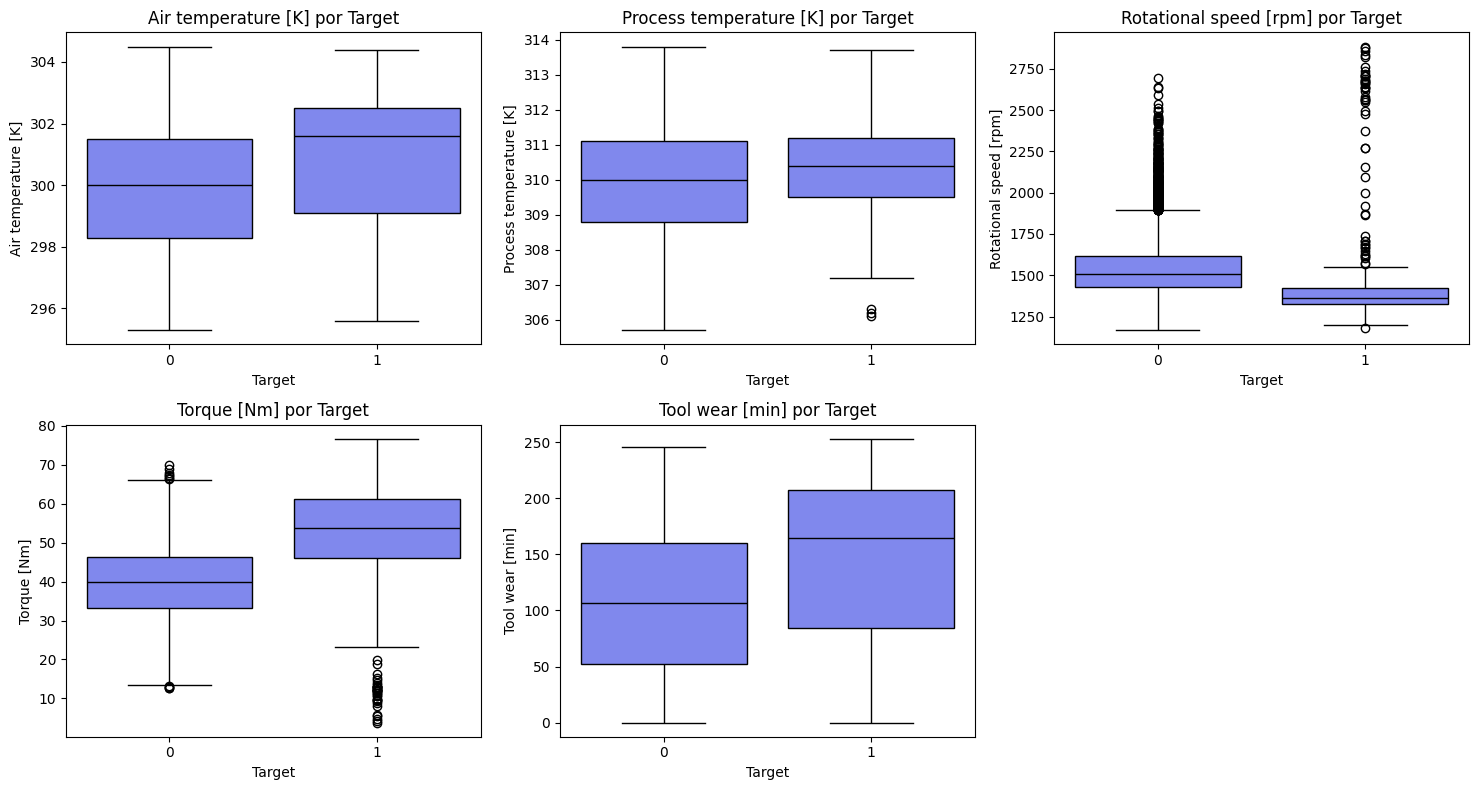

In [12]:
#Diagrama de caja
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

#Target 1 es q fallo y target 0 es q no fallo

for i, var in enumerate(variables_numericas):
    sns.boxplot(data=df, x='Target', y=var, ax=axes[i], color="#6e78ff", linecolor='black')
    axes[i].set_title(f'{var} por Target')

plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

## **Manejo de outliers**

A partir del análisis visual y numérico del los diagramas de caja y el criterio de rango intercuartílico IQR, podemos evidenciar valores atípicos notables en variables como Process Temperature [K], Rotational speed [rpm] y Torque [Nm]. Se decide conservar estos outliers porque corresponden a condiciones reales previas a un fallo, no a errores de captura.

### Distribución de variables categóricas
Se visualiza la distribución de `Target`, `Failure Type` y `Type`, confirmando el
fuerte desbalance de clases: solo 3.39% de los registros corresponden a fallos (Target=1).

Target
0    9661
1     339
Name: count, dtype: int64

Porcentaje:
Target
0    96.61
1     3.39
Name: proportion, dtype: float64
---------------------------------
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Porcentaje:
Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64
---------------------------------
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Porcentaje:
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


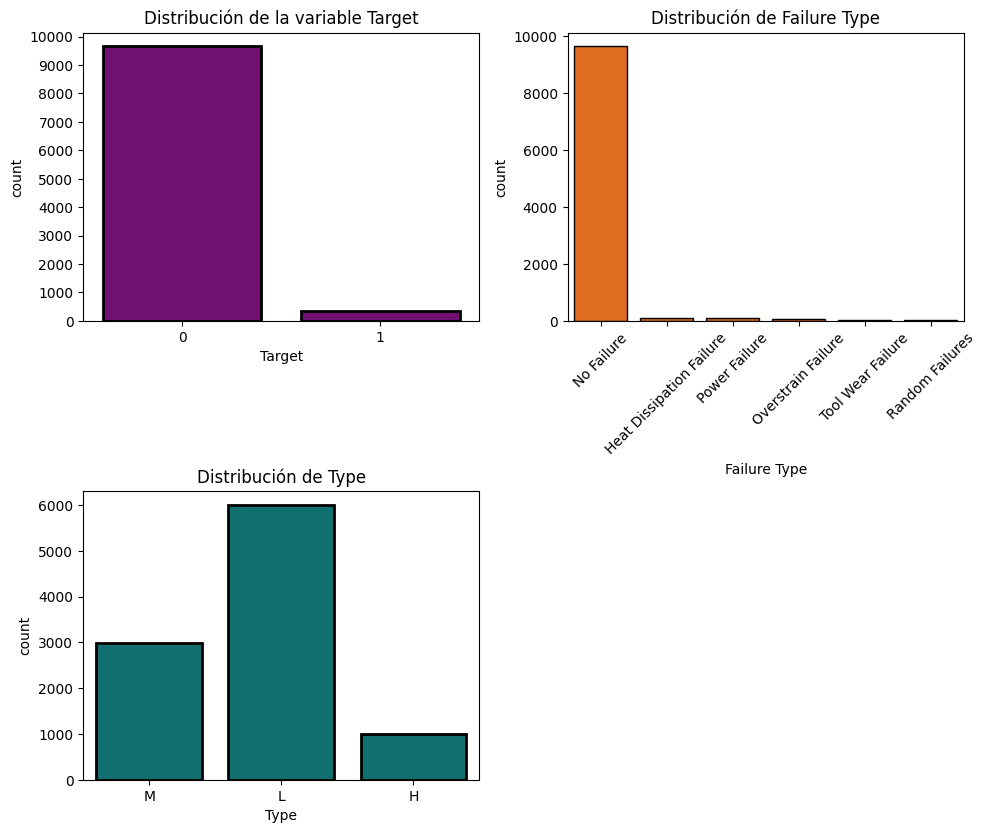

In [13]:

print(df["Target"].value_counts())
print("\nPorcentaje:")
print(df["Target"].value_counts(normalize=True)*100)
print("---------------------------------")
print(df["Failure Type"].value_counts())
print("\nPorcentaje:")
print(df["Failure Type"].value_counts(normalize=True)*100)
print("---------------------------------")
print(df["Type"].value_counts())
print("\nPorcentaje:")
print(df["Type"].value_counts(normalize=True)*100)

#Distribuciones
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.countplot(data=df, x='Target', color="purple", edgecolor="black", linewidth=2)
plt.title('Distribución de la variable Target')
plt.locator_params(axis='y', nbins=20)


plt.subplot(2,2,2)
sns.countplot(data=df, x='Failure Type', order=df['Failure Type'].value_counts().index, color="#FF6600", edgecolor="black", linewidth=1)
plt.xticks(rotation=45)
plt.title('Distribución de Failure Type')
plt.tight_layout()

plt.subplot(2,2,3)
sns.countplot(data=df, x='Type', color="#008080", edgecolor="black", linewidth=2)
plt.title('Distribución de Type')
plt.show()




### Tipos de falla en máquinas que fallaron
Se filtran únicamente los registros donde ocurrió un fallo para analizar cuáles tipos
de falla (`Failure Type`) son más frecuentes

Distribución de tipos de falla (solo donde fallo):
Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Name: count, dtype: int64

En porcentaje:
Failure Type
Heat Dissipation Failure    33.038348
Power Failure               28.023599
Overstrain Failure          23.008850
Tool Wear Failure           13.274336
No Failure                   2.654867
Name: proportion, dtype: float64


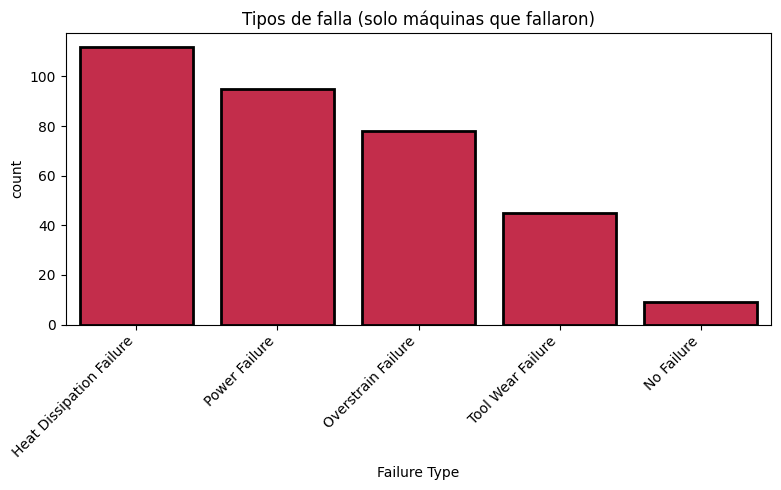

In [14]:
# los casos donde la máquina falló
fallas = df[df['Target'] == 1]

print("Distribución de tipos de falla (solo donde fallo):")
print(fallas['Failure Type'].value_counts())
print("\nEn porcentaje:")
print(fallas['Failure Type'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=fallas, x='Failure Type',
              order=fallas['Failure Type'].value_counts().index, color='crimson', edgecolor="black", linewidth=2)
plt.title('Tipos de falla (solo máquinas que fallaron)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribuciones por clase (densidad)
Dado el desbalance de clases, se usan histogramas normalizados por densidad (en lugar
de conteo) para poder comparar de forma justa la forma de las distribuciones entre
máquinas que fallaron y las que no.

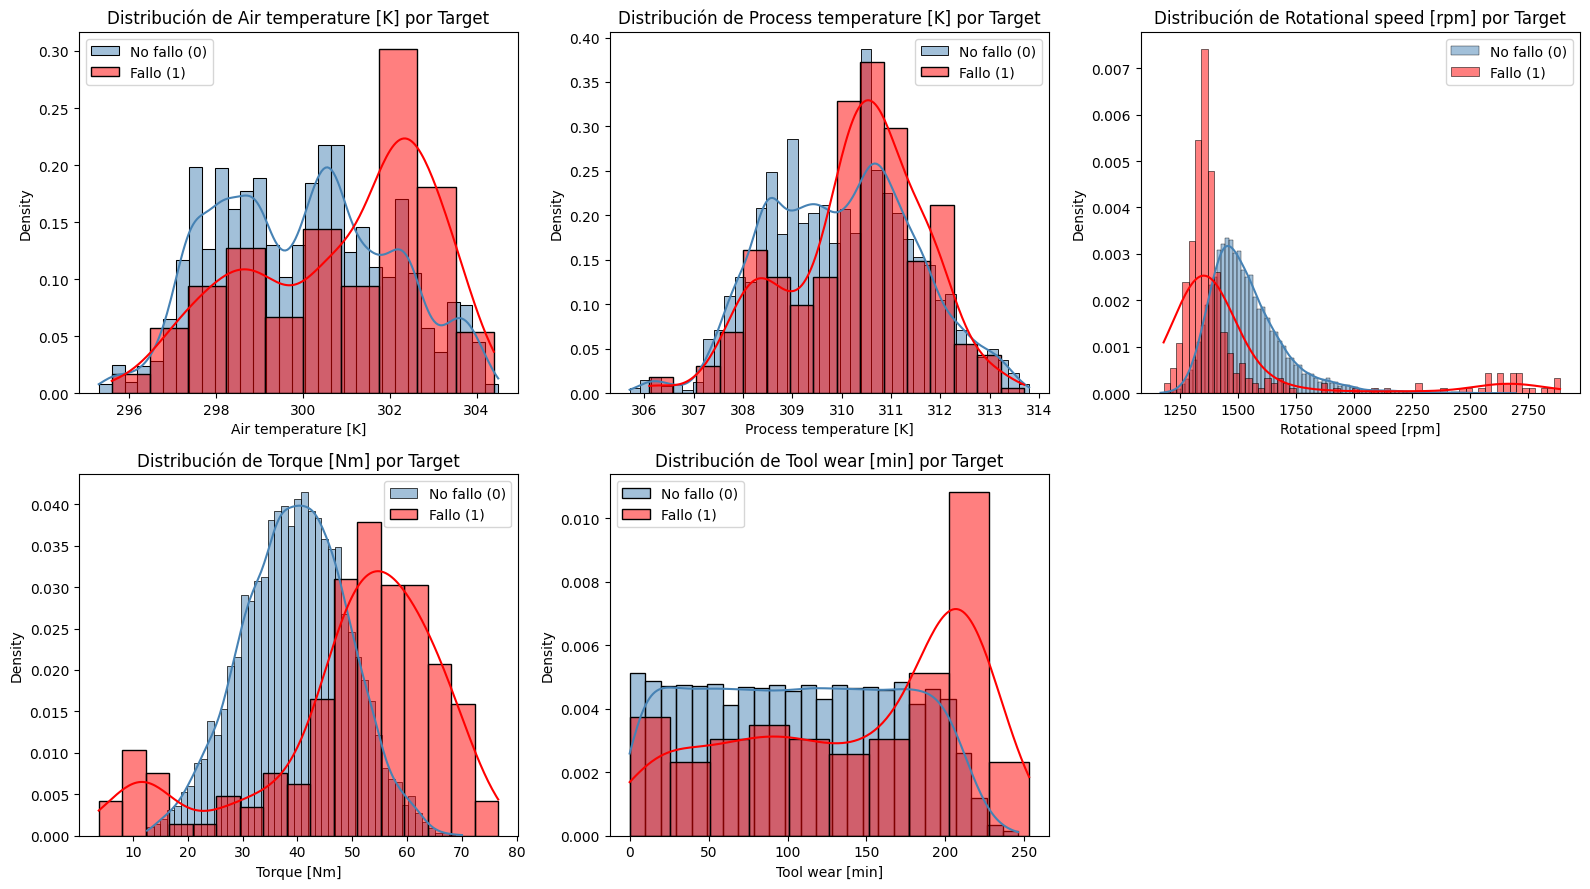

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    sns.histplot(data=df[df['Target']==0], x=var, kde=True, stat='density',
                 color='steelblue', label='No fallo (0)', ax=axes[i], alpha=0.5)
    sns.histplot(data=df[df['Target']==1], x=var, kde=True, stat='density',
                 color='red', label='Fallo (1)', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Distribución de {var} por Target')
    axes[i].legend()

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### Relación entre tipo de máquina y tipo de falla
Esta tabla cruzada muestra la relación entre el tipo de máquina (L, M, H) y el tipo de falla presentada, considerando únicamente los casos donde sí ocurrió una falla. El mapa de calor permite identificar si ciertos tipos de máquina están más asociados a modos de falla específicos, lo cual es útil para entender no solo si una máquina falla, sino qué tipo de falla es más probable según sus características.

Failure Type  Heat Dissipation Failure  No Failure  Overstrain Failure  \
Type                                                                     
H                                    8           1                   1   
L                                   74           4                  73   
M                                   30           4                   4   

Failure Type  Power Failure  Tool Wear Failure  
Type                                            
H                         5                  6  
L                        59                 25  
M                        31                 14  


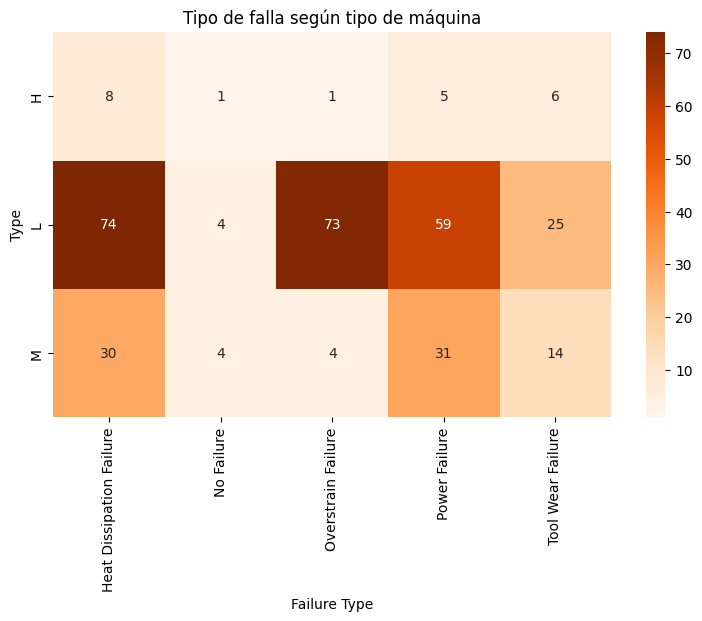

In [16]:
tabla_fallas = pd.crosstab(df['Type'], fallas['Failure Type'])
# usamos df['Type'] completo pero fallas['Failure Type'] solo tiene las filas con falla,
# se rellena con NaN donde no aplica

tabla_fallas = pd.crosstab(df.loc[fallas.index, 'Type'], fallas['Failure Type'])
print(tabla_fallas)

plt.figure(figsize=(9, 5))
sns.heatmap(tabla_fallas, annot=True, fmt='d', cmap='Oranges')
plt.title('Tipo de falla según tipo de máquina')
plt.show()

### Matriz de correlación
Se analiza la correlación de todas las variables numéricas con `Target`, ordenando la
matriz según la magnitud de esta relación. `Torque` (0.19) y `Tool wear` (0.11) muestran
las correlaciones más altas con la variable objetivo, aunque en general las relaciones
lineales son débiles,esto es algo esperado dado que los fallos suelen depender de combinaciones
de variables más que de una sola.

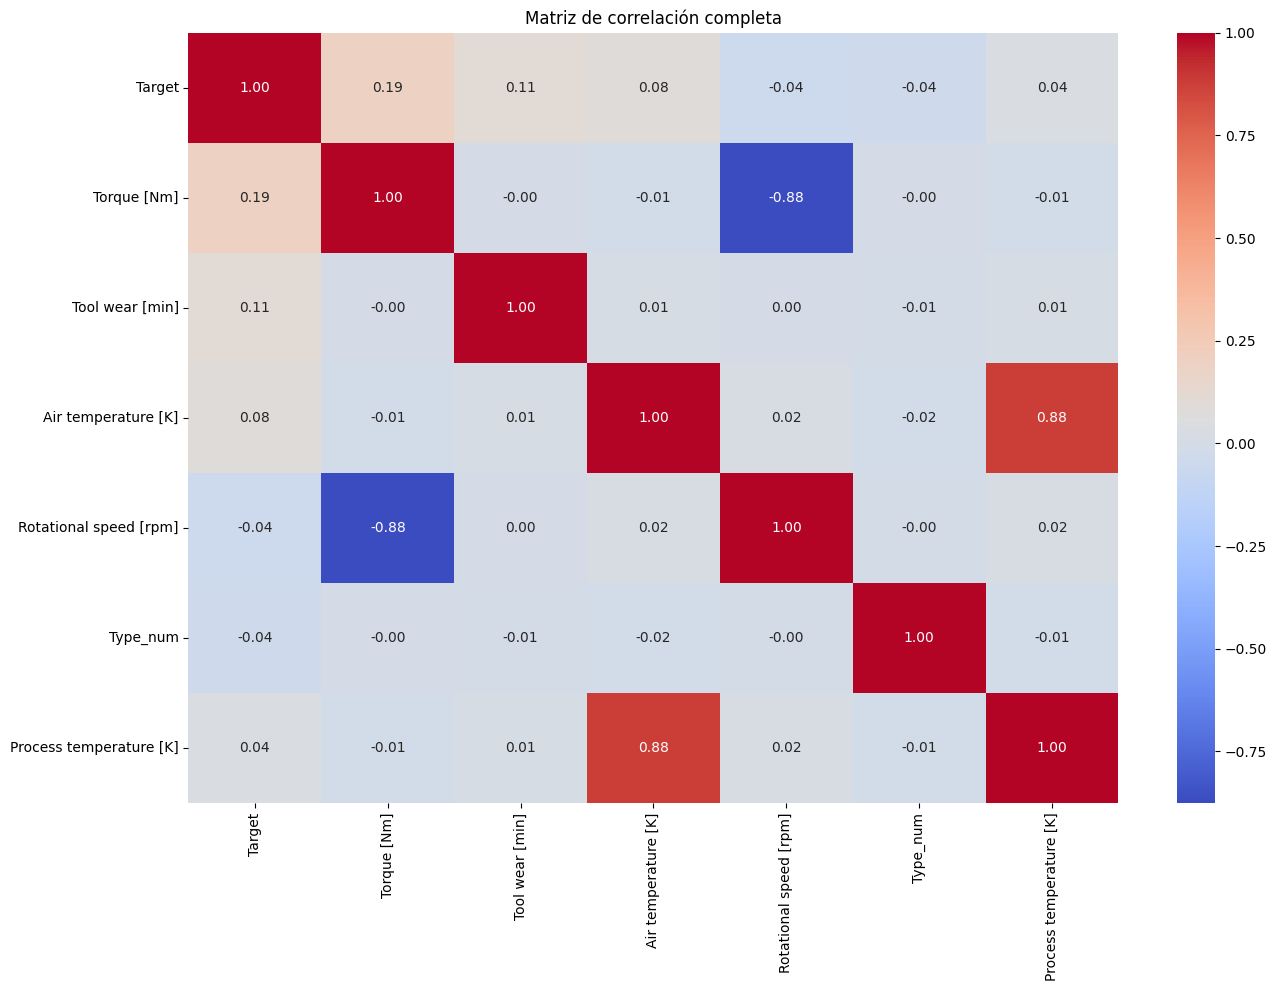

In [17]:
df['Type_num'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

corr = df.drop(columns=['UDI', 'Product ID', 'Failure Type', 'Type']).corr(numeric_only=True)

#aqui se ordenanlas variables segun su relacion con target
orden = corr['Target'].abs().sort_values(ascending=False).index
corr_ordenada = corr.loc[orden, orden]

plt.subplots(figsize=(15,10))
sns.heatmap(corr_ordenada, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación completa')
plt.show()




###**Nueva Variable**:Temp_diff

Se creó una nueva variable, Temp_diff, calculada como la diferencia entre la temperatura del proceso y la temperatura del aire. Esta variable busca capturar el efecto del calentamiento del proceso respecto a las condiciones ambientales, lo cual puede ser más informativo que analizar ambas temperaturas por separado. Se comparó su distribución entre máquinas que fallaron y las que no, y se evaluó su correlación con la variable objetivo (Target) para determinar si aporta más información que las variables originales.

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temp_diff, dtype: float64


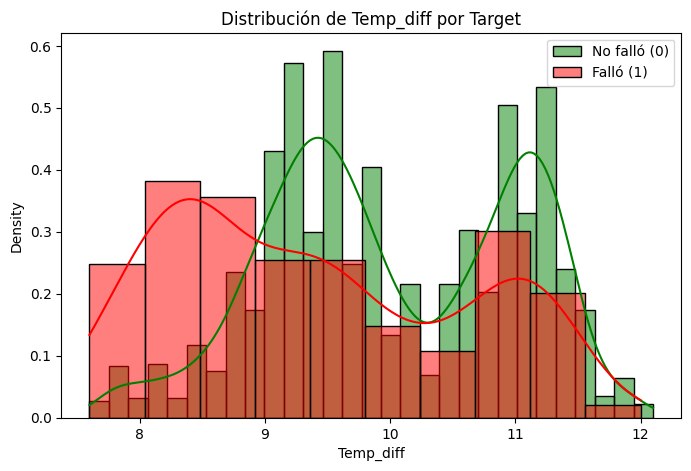

Torque [Nm]                0.191321
Temp_diff                 -0.111676
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Target, dtype: float64


In [18]:

df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']


print(df['Temp_diff'].describe())


plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['Target']==0], x='Temp_diff', kde=True, stat='density',
             color='green', label='No falló (0)', alpha=0.5)
sns.histplot(data=df[df['Target']==1], x='Temp_diff', kde=True, stat='density',
             color='red', label='Falló (1)', alpha=0.5)
plt.title('Distribución de Temp_diff por Target')
plt.legend()
plt.show()


variables_numericas2 = variables_numericas + ['Temp_diff']
corr = df[variables_numericas2 + ['Target']].corr()
corr_target = corr['Target'].drop('Target').sort_values(key=abs, ascending=False)
print(corr_target)

La variable `Temp_diff` muestra una distribución distinta entre clases, lo que indica
que podría aportar información adicional respecto a las temperaturas individuales.

### Conclusiones del análisis exploratorio
- El dataset no presenta valores nulos ni duplicados, por lo que no se requiere metodos de limpieza o imputación de datos.
- En cuanto a las variables cuantitativas, `Air Temperature` y `Process Temperature` muestran comportamiento multimodal, `Rotational speed` y `Torque` presentan valores atípicos operativos,  y `Tool wear` tiene una distribución asimétrica.
- Existe un fuerte desbalance de clases (3.39% de fallos), por lo que se deberán usar
  técnicas de balanceo (SMOTE, undersampling) o métricas adecuadas (F1, recall, AUC) en la etapa de modelado.
- `Torque` y `Tool wear` son las variables con mayor relación individual con el Target y La variable categórica `Type` influye tanto en la frecuencia general de fallos como en el tipo específico de falla presentada.
- El tipo de máquina influye en el tipo de falla presentada, no solo en su ocurrencia.
- La variable derivada `Temp_diff` aporta información adicional sobre la disipación térmica y se evaluará su
  utilidad en el modelo.



### Próximos pasos
Para la etapa de modelado se plantea:
 manejar el desbalance de clases con

*   codificar la variable categórica `Type` (One-Hot Encoding)
*  incluir `Temp_diff` como variable
predictora adicional dado que mostró diferencias entre clases
*  probar modelos
robustos a outliers como Random Forest o XGBoost como primera aproximación.